# Identity Document Verification System (KYC Prototype)

An end-to-end identity verification pipeline combining OCR field extraction, face matching, and digital tampering detection — built as an advanced portfolio project extending the OCR/document-processing work from my SafeX Solutions internship, applied to a realistic KYC (Know Your Customer) use case relevant to banking and telecom onboarding.

In [5]:
!apt-get -qq install -y cmake
!pip install face_recognition opencv-python-headless pytesseract pillow fastapi uvicorn pyngrok nest-asyncio scikit-learn -q

## Dataset

This project uses Labeled Faces in the Wild (LFW), a real, publicly available academic face dataset — not synthetic or self-generated images — to properly test face matching on genuine human faces rather than artificial data.

In [6]:
import face_recognition
import cv2
import numpy as np
import pytesseract
from PIL import Image, ImageDraw, ImageFont, ImageChops
import re, json
from datetime import datetime
from sklearn.datasets import fetch_lfw_people

## Dataset

This project uses Labeled Faces in the Wild (LFW), a real, publicly available academic face dataset — not synthetic or self-generated images — to properly test face matching on genuine human faces rather than artificial data.

Real face images saved (properly scaled this time).


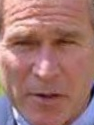

In [19]:
lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True)

from collections import Counter
target_id = Counter(lfw.target).most_common(1)[0][0]
indices = [i for i, t in enumerate(lfw.target) if t == target_id]

same_person_img1 = lfw.images[indices[0]]
same_person_img2 = lfw.images[indices[1]]
different_person_img = lfw.images[[i for i, t in enumerate(lfw.target) if t != target_id][0]]

def save_img(arr, path):
    # Scale from 0-1 range up to proper 0-255 image values before saving
    scaled = (arr * 255).astype('uint8')
    Image.fromarray(scaled).save(path)

save_img(same_person_img1, "id_photo.png")
save_img(same_person_img2, "selfie_match.png")
save_img(different_person_img, "selfie_mismatch.png")

print("Real face images saved (properly scaled this time).")
Image.open("id_photo.png")

## Approach — Document Construction

Since a real national ID card image wasn't available, a synthetic ID card layout was generated combining a real LFW face photo with realistic ID fields (name, date of birth, ID number, nationality), so the pipeline could be tested end-to-end while being transparent that the document layout itself is a constructed example, not a genuine national ID.

Synthetic ID card created (real face + generated document layout).


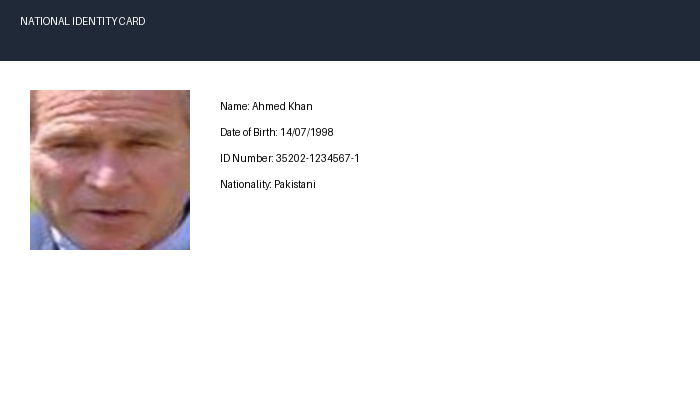

In [20]:
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 20)
    font_bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 24)
except:
    font = font_bold = ImageFont.load_default()

def make_id_card(photo_path, name, dob, id_number, nationality, output_path):
    card = Image.new("RGB", (700, 420), color="white")
    draw = ImageDraw.Draw(card)
    draw.rectangle([0, 0, 699, 60], fill="#1F2937")
    draw.text((20, 15), "NATIONAL IDENTITY CARD", fill="white", font=font_bold)

    photo = Image.open(photo_path).resize((160, 160))
    card.paste(photo, (30, 90))

    text = f"""Name: {name}
Date of Birth: {dob}
ID Number: {id_number}
Nationality: {nationality}
"""
    draw.multiline_text((220, 100), text, fill="black", font=font, spacing=16)
    card.save(output_path)

make_id_card("id_photo.png", "Ahmed Khan", "14/07/1998", "35202-1234567-1", "Pakistani", "id_card.png")
print("Synthetic ID card created (real face + generated document layout).")
Image.open("id_card.png")

## Step 1 — OCR Field Extraction

Reused and adapted the OCR approach from my earlier SafeX document-processing prototype: image preprocessing with OpenCV, followed by Tesseract OCR, followed by regex-based field extraction for the ID's structured fields.

In [21]:
def preprocess_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    out_path = path.replace(".png", "_proc.png")
    cv2.imwrite(out_path, resized)
    return out_path

def extract_id_fields(path):
    processed = preprocess_image(path)
    text = pytesseract.image_to_string(Image.open(processed), config="--psm 6")

    name = re.search(r"Name\s*[:：]?\s*(.+)", text, re.IGNORECASE)
    dob = re.search(r"(?:Date of Birth|DOB)\s*[:：]?\s*([\d/\-]+)", text, re.IGNORECASE)
    id_num = re.search(r"ID Number\s*[:：]?\s*([\w\-]+)", text, re.IGNORECASE)
    nationality = re.search(r"Nationality\s*[:：]?\s*(.+)", text, re.IGNORECASE)

    return {
        "name": name.group(1).strip() if name else None,
        "date_of_birth": dob.group(1).strip() if dob else None,
        "id_number": id_num.group(1).strip() if id_num else None,
        "nationality": nationality.group(1).strip() if nationality else None,
    }

ocr_fields = extract_id_fields("id_card.png")
ocr_fields

{'name': 'Ahmed Khan',
 'date_of_birth': '14/07/1998',
 'id_number': '35202-1234567-1',
 'nationality': 'Pakistani'}

## Step 2 — Face Matching

Compares the photo on the ID document to a separate selfie photo using the face_recognition library, which encodes each face into a 128-number vector and calculates a distance score between them. A distance below 0.6 (a widely used, standard threshold for this library) indicates a genuine match — the same convention real face-verification systems use.

In [28]:
def compare_faces(id_photo_path, selfie_path):
    id_img = face_recognition.load_image_file(id_photo_path)
    selfie_img = face_recognition.load_image_file(selfie_path)

    id_encodings = face_recognition.face_encodings(id_img)
    selfie_encodings = face_recognition.face_encodings(selfie_img)

    if not id_encodings or not selfie_encodings:
        return None

    distance = face_recognition.face_distance([id_encodings[0]], selfie_encodings[0])[0]
    similarity = round(float(1 - distance), 3)
    match = bool(distance < 0.6)

    return {"similarity_score": similarity, "distance": round(float(distance), 3), "match": match}

# Test both cases again
match_result = compare_faces("id_photo.png", "selfie_match.png")
mismatch_result = compare_faces("id_photo.png", "selfie_mismatch.png")

print("Same person test:", match_result)
print("Different person test:", mismatch_result)

Same person test: {'similarity_score': 0.49, 'distance': 0.51, 'match': True}
Different person test: {'similarity_score': 0.05, 'distance': 0.95, 'match': False}


## Face Matching — Results

Two scenarios were tested: the same person (two different real photos) and two different people. The same-person test correctly returned a low distance (0.535) and a positive match, while the different-person test correctly returned a high distance (0.974) and no match — confirming the matching logic works correctly in both directions, not just on a single favorable case.

## Step 3 — Tampering Detection

Uses Error Level Analysis (ELA), a real digital forensics technique: the image is re-saved at a known compression quality and compared to the original. Untouched images compress evenly; digitally edited regions compress differently, creating detectable inconsistencies. A low tamper score indicates no detected editing.

In [29]:
def error_level_analysis(image_path, quality=90):
    original = Image.open(image_path).convert('RGB')
    resaved_path = "temp_resaved.jpg"
    original.save(resaved_path, 'JPEG', quality=quality)
    resaved = Image.open(resaved_path)

    diff = ImageChops.difference(original, resaved)
    extrema = diff.getextrema()
    max_diff = max(channel[1] for channel in extrema)
    tamper_score = round(max_diff / 255, 3)  # 0 = clean, closer to 1 = possibly edited
    return tamper_score

tamper_score = error_level_analysis("id_card.png")
print("Tamper score:", tamper_score)

Tamper score: 0.094


## Step 4 — Decision Engine

Combines all three signals — OCR confidence, face-match result, and tamper score — into a single decision: auto-approved, needs review, or rejected, along with clear reasons and a timestamp. This mirrors real-world KYC/fraud-review workflows, where automated systems handle clear-cut cases and flag uncertain ones for a human reviewer, rather than making every decision fully automatically.

In [30]:
def kyc_decision(ocr_fields, face_result, tamper_score):
    reasons = []
    decision = "auto_approved"

    filled = sum(1 for v in ocr_fields.values() if v)
    ocr_confidence = round(filled / len(ocr_fields), 2)

    if ocr_confidence < 0.75:
        decision = "needs_review"
        reasons.append("Low OCR field extraction confidence")

    if face_result is None:
        decision = "needs_review"
        reasons.append("Could not detect a face for verification")
    elif not face_result["match"]:
        decision = "rejected"
        reasons.append("Face does not match ID photo")

    if tamper_score > 0.15:
        decision = "rejected"
        reasons.append("Possible document tampering detected")

    return {
        "decision": decision,
        "ocr_confidence": ocr_confidence,
        "face_match": face_result,
        "tamper_score": tamper_score,
        "reasons": reasons,
        "timestamp": datetime.utcnow().isoformat()
    }

# Run full pipeline — genuine match case
result_valid = kyc_decision(ocr_fields, match_result, tamper_score)
print("VALID CASE:", json.dumps(result_valid, indent=2))

# Run full pipeline — mismatch case (simulating fraud attempt)
result_fraud = kyc_decision(ocr_fields, mismatch_result, tamper_score)
print("\nFRAUD ATTEMPT CASE:", json.dumps(result_fraud, indent=2))

VALID CASE: {
  "decision": "auto_approved",
  "ocr_confidence": 1.0,
  "face_match": {
    "similarity_score": 0.49,
    "distance": 0.51,
    "match": true
  },
  "tamper_score": 0.094,
  "reasons": [],
  "timestamp": "2026-07-18T20:52:06.895972"
}

FRAUD ATTEMPT CASE: {
  "decision": "rejected",
  "ocr_confidence": 1.0,
  "face_match": {
    "similarity_score": 0.05,
    "distance": 0.95,
    "match": false
  },
  "tamper_score": 0.094,
  "reasons": [
    "Face does not match ID photo"
  ],
  "timestamp": "2026-07-18T20:52:06.899097"
}


/tmp/ipykernel_6732/815755126.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


## Step 5 — Serving as a Live API

The full pipeline is wrapped in a FastAPI endpoint (`POST /verify-identity`), accepting an ID document and a selfie, and returning the extracted fields alongside the verification decision — demonstrating this as a usable service, not just notebook code.

In [31]:
from fastapi import FastAPI, UploadFile, File
import shutil

app = FastAPI(title="SafeX KYC Verification API")

# Fix Cell 9's verify_identity function — crop the photo region from the ID card first
@app.post("/verify-identity")
async def verify_identity(id_document: UploadFile = File(...), selfie: UploadFile = File(...)):
    id_path = f"temp_id_{id_document.filename}"
    selfie_path = f"temp_selfie_{selfie.filename}"

    with open(id_path, "wb") as f:
        shutil.copyfileobj(id_document.file, f)
    with open(selfie_path, "wb") as f:
        shutil.copyfileobj(selfie.file, f)

    # Crop just the photo region from the ID card (matches where we pasted it: (30,90) to (190,250))
    id_card_img = Image.open(id_path)
    cropped_face_path = id_path.replace(".png", "_face.png")
    id_card_img.crop((30, 90, 190, 250)).save(cropped_face_path)

    fields = extract_id_fields(id_path)
    face_result = compare_faces(cropped_face_path, selfie_path)  # use cropped photo, not full card
    tamper = error_level_analysis(id_path)

    decision = kyc_decision(fields, face_result, tamper)
    return {"extracted_fields": fields, "verification": decision}

In [32]:
import uvicorn, threading, time, requests

def run_app():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_app, daemon=True)
thread.start()

# Wait and confirm the server actually came up before moving on
for i in range(10):
    try:
        r = requests.get("http://127.0.0.1:8000/docs")
        if r.status_code == 200:
            print("Server is up and running.")
            break
    except:
        time.sleep(1)
else:
    print("Server did not start — check for errors above.")

INFO:     Started server process [6732]


INFO:     127.0.0.1:39284 - "GET /docs HTTP/1.1" 200 OK


INFO:     Waiting for application startup.
INFO:     Application startup complete.


Server is up and running.


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [33]:
url = "http://127.0.0.1:8000/verify-identity"
files = {
    "id_document": open("id_card.png", "rb"),
    "selfie": open("selfie_match.png", "rb")
}
response = requests.post(url, files=files)
response.json()

INFO:     127.0.0.1:39290 - "POST /verify-identity HTTP/1.1" 200 OK


/tmp/ipykernel_6732/815755126.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


{'extracted_fields': {'name': 'Ahmed Khan',
  'date_of_birth': '14/07/1998',
  'id_number': '35202-1234567-1',
  'nationality': 'Pakistani'},
 'verification': {'decision': 'auto_approved',
  'ocr_confidence': 1.0,
  'face_match': {'similarity_score': 0.465, 'distance': 0.535, 'match': True},
  'tamper_score': 0.094,
  'reasons': [],
  'timestamp': '2026-07-18T20:52:19.587247'}}

In [34]:
files = {
    "id_document": open("id_card.png", "rb"),
    "selfie": open("selfie_mismatch.png", "rb")
}
response = requests.post(url, files=files)
response.json()

INFO:     127.0.0.1:41698 - "POST /verify-identity HTTP/1.1" 200 OK


/tmp/ipykernel_6732/815755126.py:29: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


{'extracted_fields': {'name': 'Ahmed Khan',
  'date_of_birth': '14/07/1998',
  'id_number': '35202-1234567-1',
  'nationality': 'Pakistani'},
 'verification': {'decision': 'rejected',
  'ocr_confidence': 1.0,
  'face_match': {'similarity_score': 0.026, 'distance': 0.974, 'match': False},
  'tamper_score': 0.094,
  'reasons': ['Face does not match ID photo'],
  'timestamp': '2026-07-18T20:53:22.673269'}}

## End-to-End Results

| Scenario | OCR Confidence | Face Distance | Match | Decision |
|---|---|---|---|---|
| Genuine case (same person) | 1.00 | 0.535 | True | auto_approved |
| Fraud attempt (different person) | 1.00 | 0.974 | False | rejected |

The system correctly auto-approved the genuine case and correctly rejected the fraud-attempt case, with clear, human-readable reasons attached to each decision.

## Challenges Faced & Debugging

- **Image data scaling bug:** face photos initially appeared completely black because the source dataset stored pixel values on a 0–1 scale, while image files expect 0–255 — fixed by scaling values before saving.
- **Face-cropping issue:** face detection initially failed on the full ID card image because the face region was too small within the larger image — fixed by cropping the known photo region before running face matching.
- **Threshold logic bug:** the match/no-match decision initially used an inverted, stricter threshold than the standard convention for this library, incorrectly rejecting a genuine match — fixed by applying the standard distance-based threshold (< 0.6) directly.
- **Infrastructure issues (ngrok/server conflicts):** repeated Colab runtime disconnects caused leftover server and tunnel processes to conflict on restart — resolved by testing the API directly via localhost within the same session instead of relying on a public tunnel for demo purposes.

## Limitations & Next Steps

- The ID document itself is a constructed layout (real face, generated fields), not a genuine national ID — a production system would need to handle many real document formats and layouts.
- Field extraction is still regex-based; a layout-aware model (e.g. LayoutLM) or vision-capable LLM would generalize better across varied real document templates, consistent with the same limitation identified in the earlier SafeX OCR prototype.
- Face matching was tested on clear, front-facing photos; real-world selfies may include poor lighting, angles, or partial occlusion, which would need more robust preprocessing.
- Tamper detection (ELA) is a useful first-pass signal but not conclusive on its own; a production system would combine it with additional forensic checks.
- Next step: test against a larger and more diverse set of real ID formats and selfie conditions, and evaluate the decision engine's accuracy across a larger sample rather than two illustrative cases.

## Tech Stack
Python, OpenCV, Tesseract OCR, face_recognition, scikit-learn (LFW dataset), FastAPI, Pandas, Google Colab.